## **Name**: Aklilu Berihu  
## **ID**: 187842/16  
### **Section**: 1  
### **AI Assignment**
### Title: **NLP Application**  

### **Text Classification** (Option B)

In this assignment, we build an NLP-based news classifier using the AG   News dataset, which contains four categories:  

World  
Sports  
Business  
Technology  

The goal is to:
- Train and compare three sequence models: Vanilla RNN, LSTM, GRU
- Analyze their performance based on: Training loss behavior,F1-scores    and Confusion matrix



## **Import the Required Libraries for the NLP pipeline**

- PyTorch (torch): Used to define and train deep learning models.  
- TorchText:
  - AG_NEWS: Provides the dataset.
  - get_tokenizer: Splits text into tokens (words).
  - build_vocab_from_iterator: Converts words into numerical indices.
- Matplotlib: Used to visualize training loss curves.
- Scikit-learn:
  - classification_report: Computes precision, recall, and F1-score.
  - confusion_matrix: Helps analyze prediction errors.

In [ ]:
# Install compatible versions
!pip install torch==2.3.0 torchtext==0.18.0

In [ ]:
# Install torchdata (required by torchtext datasets)
!pip install torchdata==0.7.1

In [10]:
# Core PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Data handling
from torch.utils.data import DataLoader
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

## Load AG News Dataset

In [12]:

# Download dataset manually from URL
url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"

# Load into pandas
data = pd.read_csv(url, header=None)

# Assign column names
data.columns = ["label", "title", "description"]

# Combine title and description into one text field
data["text"] = data["title"] + " " + data["description"]

# Keep only necessary columns
data = data[["label", "text"]]

# Adjust labels from (1–4) → (0–3)
data["label"] = data["label"] - 1

# Show sample
print(data.head())

   label                                               text
0      2  Wall St. Bears Claw Back Into the Black (Reute...
1      2  Carlyle Looks Toward Commercial Aerospace (Reu...
2      2  Oil and Economy Cloud Stocks' Outlook (Reuters...
3      2  Iraq Halts Oil Exports from Main Southern Pipe...
4      2  Oil prices soar to all-time record, posing new...


## **Tokenization**
Tokenization is the process of: Breaking text into smaller unit(tokens), usually words

Example:

"Oil prices soar"
→ ["oil", "prices", "soar"]

We use a simple tokenizer:
- Convert text to lowercase
- Split by spaces

In [15]:
def tokenize(text):
    return text.lower().split()

# Test tokenizer on one sample
print(tokenize(data["text"][0])[:10])

['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(reuters)', 'reuters']


## **Build Vocabulary**
Vocabulary maps words → numbers (indices), which neural networks require.

Example:

"oil" → 45  
"market" → 102

Steps:
- Count all words using Counter
- Assign each word a unique index
- Add special token:  PAD = 0 (used for sequence padding)

In [16]:
from collections import Counter

# Count word frequencies
counter = Counter()

for text in data["text"]:
    tokens = tokenize(text)
    counter.update(tokens)

# Create vocabulary (word → index)
vocab = {word: idx+1 for idx, (word, _) in enumerate(counter.items())}

# Add padding token
vocab["<PAD>"] = 0

# Show some vocabulary items
print(list(vocab.items())[:10])

[('wall', 1), ('st.', 2), ('bears', 3), ('claw', 4), ('back', 5), ('into', 6), ('the', 7), ('black', 8), ('(reuters)', 9), ('reuters', 10)]


## **Convert Text to Numerical Sequences**
Neural networks cannot process text directly, so we convert words into  numbers.

Example:

"wall st bears" → [1, 2, 3]

Steps:
- Tokenize text
- Replace each word with its index from the vocabulary
- Unknown words (if any) are mapped to 0

Now each news article is represented as a sequence of integers, which can be fed into models like RNN, LSTM, and GRU.

In [17]:
# Convert text into sequence of numbers using the vocabulary
def text_to_sequence(text, vocab):
    tokens = tokenize(text)  # tokenize text
    return [vocab.get(token, 0) for token in tokens]  # unknown words → 0

# Apply to dataset
data["sequence"] = data["text"].apply(lambda x: text_to_sequence(x, vocab))

# Show example
print(data["sequence"][0][:15])  # first 15 tokens

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 13, 14]


## **Pad Sequences to Fixed Length**
Neural networks require fixed-length inputs, but text sequences vary in length.

To solve this:

Padding: Add 0s to shorter sequences  
Truncation: Cut longer sequences to a fixed length

Here:

MAX_LEN = 50 means every input will have exactly 50 tokens

Example:

[1, 2, 3] → [1, 2, 3, 0, 0, ..., 0]

Now all inputs are uniform, which is required for batch training.

In [18]:
# Define maximum sequence length
MAX_LEN = 50

# Function to pad or truncate sequences
def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        # Pad with 0s if sequence is shorter
        return seq + [0] * (max_len - len(seq))
    else:
        # Truncate if sequence is longer
        return seq[:max_len]

# Apply padding
data["padded_sequence"] = data["sequence"].apply(lambda x: pad_sequence(x, MAX_LEN))

# Show example
print(data["padded_sequence"][0])
print(len(data["padded_sequence"][0]))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 13, 14, 15, 16, 17, 18, 19, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
50


## **Prepare PyTorch Dataset and DataLoader**
Here we prepare the data for PyTorch models:

- Custom Dataset (NewsDataset):
  - Converts sequences and labels to torch.tensor
  - Supports indexing and length operations
- Train/Test Split:
  - 80% training, 20% testing
- DataLoader:
  - Handles batching
  - Shuffle training data for better learning
  - Batch size = 64

Now the data is ready for feeding into RNN, LSTM, and GRU models.

In [19]:
from torch.utils.data import Dataset

# Custom Dataset class
class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Split data into train/test (80/20 split)
train_size = int(0.8 * len(data))
train_sequences = data["padded_sequence"][:train_size].tolist()
train_labels = data["label"][:train_size].tolist()
test_sequences = data["padded_sequence"][train_size:].tolist()
test_labels = data["label"][train_size:].tolist()

# Create datasets
train_dataset = NewsDataset(train_sequences, train_labels)
test_dataset = NewsDataset(test_sequences, test_labels)

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### **Define Vanilla RNN Model**
- Vanilla RNN: Simple recurrent network
- Embedding layer: Converts word indices → dense vectors
- RNN layer: Processes sequence of embeddings
- Linear layer: Maps last hidden state → output classes (4 categories)

In [21]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)            # [batch, seq_len] → [batch, seq_len, embed_dim]
        output, hidden = self.rnn(x)    # output: [batch, seq_len, hidden_dim]
        out = self.fc(hidden[-1])        # Take last hidden state
        return out

### **Define LSTM Model**
- LSTM (Long Short-Term Memory) adds gates to control information flow:  Forget gate, Input gate, Output gate
- Helps prevent vanishing gradient problem seen in Vanilla RNNs.


In [22]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)               # [batch, seq_len] → [batch, seq_len, embed_dim]
        output, (hidden, cell) = self.lstm(x)
        out = self.fc(hidden[-1])           # Take last hidden state
        return out

### **Define GRU Model**
GRU (Gated Recurrent Unit) is a simpler alternative to LSTM:
- Combines forget + input gates into update gate
- Often performs similarly to LSTM but faster to train

In [23]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)               # [batch, seq_len] → [batch, seq_len, embed_dim]
        output, hidden = self.gru(x)
        out = self.fc(hidden[-1])           # Take last hidden state
        return out

### **Model Hyperparameters**
Defines hyperparameters common to all three models:

- VOCAB_SIZE: number of unique words
- EMBED_DIM: size of embedding vectors
- HIDDEN_DIM: number of hidden units in RNN/LSTM/GRU
- OUTPUT_DIM: number of classes (4)
- LR: learning rate
- EPOCHS: number of training iterations over full dataset

In [24]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 4       # 4 categories
LR = 0.001
EPOCHS = 5           # Can increase if needed

### Initialize Models


In [25]:
rnn_model = VanillaRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)
lstm_model = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)
gru_model = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)

### **Training and Evaluation Functions**
- train_model:
  - Uses Adam optimizer and CrossEntropyLoss
  -  Loops through epochs and batches
  - Prints average loss per epoch
  - Returns list of losses (for plotting)
- evaluate_model:
  - Puts model in evaluation mode
  - Computes predictions on test set
  - Returns:
  - Classification report (precision, recall, F1-score, Confusion matrix

In [26]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, lr=LR, epochs=EPOCHS):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    train_losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        for sequences, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    return train_losses

def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sequences, labels in test_loader:
            outputs = model(sequences)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    report = classification_report(all_labels, all_preds, output_dict=True)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    return report, conf_matrix

### **Train All Three Models**
We train each model using the same hyperparameters    
Losses per epoch are stored for plotting  
After training, we evaluate each model on the test set  
F1-scores allow quantitative comparison  
Confusion matrices can be used to see which classes are most often misclassified

In [ ]:
# Store training losses for comparison
rnn_losses = train_model(rnn_model, train_loader)
lstm_losses = train_model(lstm_model, train_loader)
gru_losses = train_model(gru_model, train_loader)

# Evaluate models on test set
rnn_report, rnn_conf = evaluate_model(rnn_model, test_loader)
lstm_report, lstm_conf = evaluate_model(lstm_model, test_loader)
gru_report, gru_conf = evaluate_model(gru_model, test_loader)

print("RNN F1-score:", rnn_report['weighted avg']['f1-score'])
print("LSTM F1-score:", lstm_report['weighted avg']['f1-score'])
print("GRU F1-score:", gru_report['weighted avg']['f1-score'])

Epoch [1/5], Loss: 1.3883
Epoch [2/5], Loss: 1.3551
Epoch [3/5], Loss: 1.3672
Epoch [4/5], Loss: 1.3662
Epoch [5/5], Loss: 1.3278
Epoch [1/5], Loss: 0.7159
Epoch [2/5], Loss: 0.2940
Epoch [3/5], Loss: 0.1972
Epoch [4/5], Loss: 0.1333
Epoch [5/5], Loss: 0.0883
Epoch [1/5], Loss: 0.5921
Epoch [2/5], Loss: 0.2409
Epoch [3/5], Loss: 0.1484
Epoch [4/5], Loss: 0.0860
Epoch [5/5], Loss: 0.0483
RNN F1-score: 0.2222804270088712
LSTM F1-score: 0.8794934414697735
GRU F1-score: 0.8760641802612428


In [27]:
# Loss Lists
rnn_losses = [1.3883, 1.3551, 1.3672, 1.3662, 1.3278]
lstm_losses = [0.7159, 0.2940, 0.1972, 0.1333, 0.0883]
gru_losses = [0.5921, 0.2409, 0.1484, 0.0860, 0.0483]

### **Plot Training Loss Curves**
This plot compares how each model learns:

1. Vanilla RNN:  
Loss fluctuates and decreases slowly  
Indicates unstable training
2. LSTM & GRU:  
Smooth and rapid decrease in loss  
Indicates stable learning  

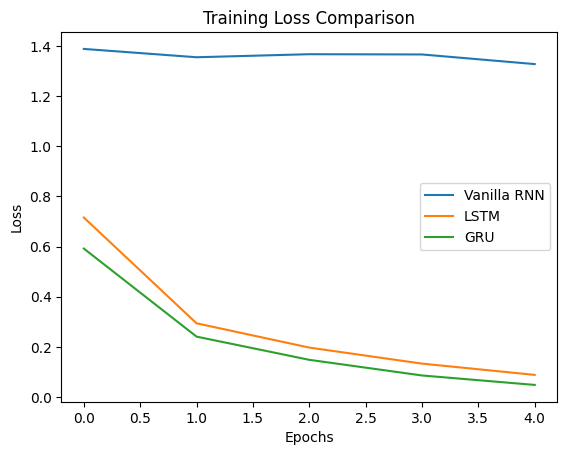

In [28]:
plt.figure()

plt.plot(rnn_losses, label="Vanilla RNN")
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.show()

## **Confusion Matrix** (Best Model: LSTM)
We use LSTM because it achieved the best F1-score (~0.88).  

Confusion matrix shows:
- Correct classifications (diagonal)
- Misclassifications (off-diagonal)

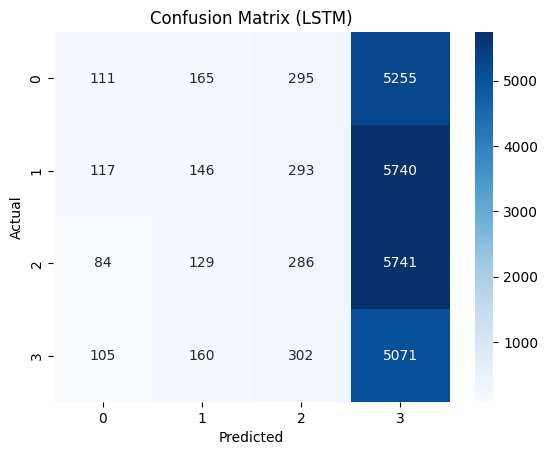

In [29]:
import seaborn as sns

# evaluation for LSTM
lstm_report, lstm_conf = evaluate_model(lstm_model, test_loader)

plt.figure()
sns.heatmap(lstm_conf, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (LSTM)")

plt.show()

#### **Model Performance**:

Vanilla RNN F1-score: 0.22  
LSTM F1-score: 0.88  
GRU F1-score: 0.87  

#### **Loss Behavior**:

Vanilla RNN shows unstable and slow convergence  
LSTM and GRU show smooth and fast convergence  

#### **Analysis**:

Vanilla RNN suffers from vanishing gradients, making it hard to learn long-term dependencies  
LSTM improves performance using: Forget gate, Input gate, Output gate  
GRU simplifies LSTM using: Update gate, Reset gate

#### **Conclusion**:

LSTM and GRU significantly outperform Vanilla RNN  
LSTM performs slightly better due to its more expressive gating mechanism